# GDP vs Life Expectancy (2000–2015)

This project investigates the relationship between a country's economic output (GDP) and the life expectancy of its citizens, using World Bank / WHO data for six countries: **Chile, China, Germany, Mexico, the USA and Zimbabwe**.

### Questions
1. Has GDP grown over time in these countries?
2. Has life expectancy increased over time?
3. Is there a correlation between GDP and life expectancy?
4. What are the average GDP and life expectancy of each country?
5. How is life expectancy distributed within each country?

#### Set Up

In [1]:
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.ticker as mtick
import numpy as np
from scipy import stats
from sklearn.preprocessing import StandardScaler

#### Preparing Data 

In [2]:
df = pd.read_csv('data/all_data.csv')
df.head()
#df.describe()

,Country,Year,Life expectancy at birth (years),GDP
0,Chile,2000,77.3,7.786093e+10
1,Chile,2001,77.3,7.097992e+10
2,Chile,2002,77.8,6.973681e+10
3,Chile,2003,77.9,7.564346e+10
4,Chile,2004,78.0,9.921039e+10


In [3]:
#Converting longer titles/names
df.rename(columns = {
    'Life expectancy at birth (years)': 'LEABY'
}, inplace = True)
df.replace('United States of America', 'USA', inplace = True)

# Convert GDP to billions of USD
df.GDP = df.GDP / 1e9
df.head()
#print(df.Country.unique())

,Country,Year,LEABY,GDP
0,Chile,2000,77.3,77.860932
1,Chile,2001,77.3,70.979924
2,Chile,2002,77.8,69.736811
3,Chile,2003,77.9,75.643460
4,Chile,2004,78.0,99.210393


### 1. Analysing Data for GDP Growth

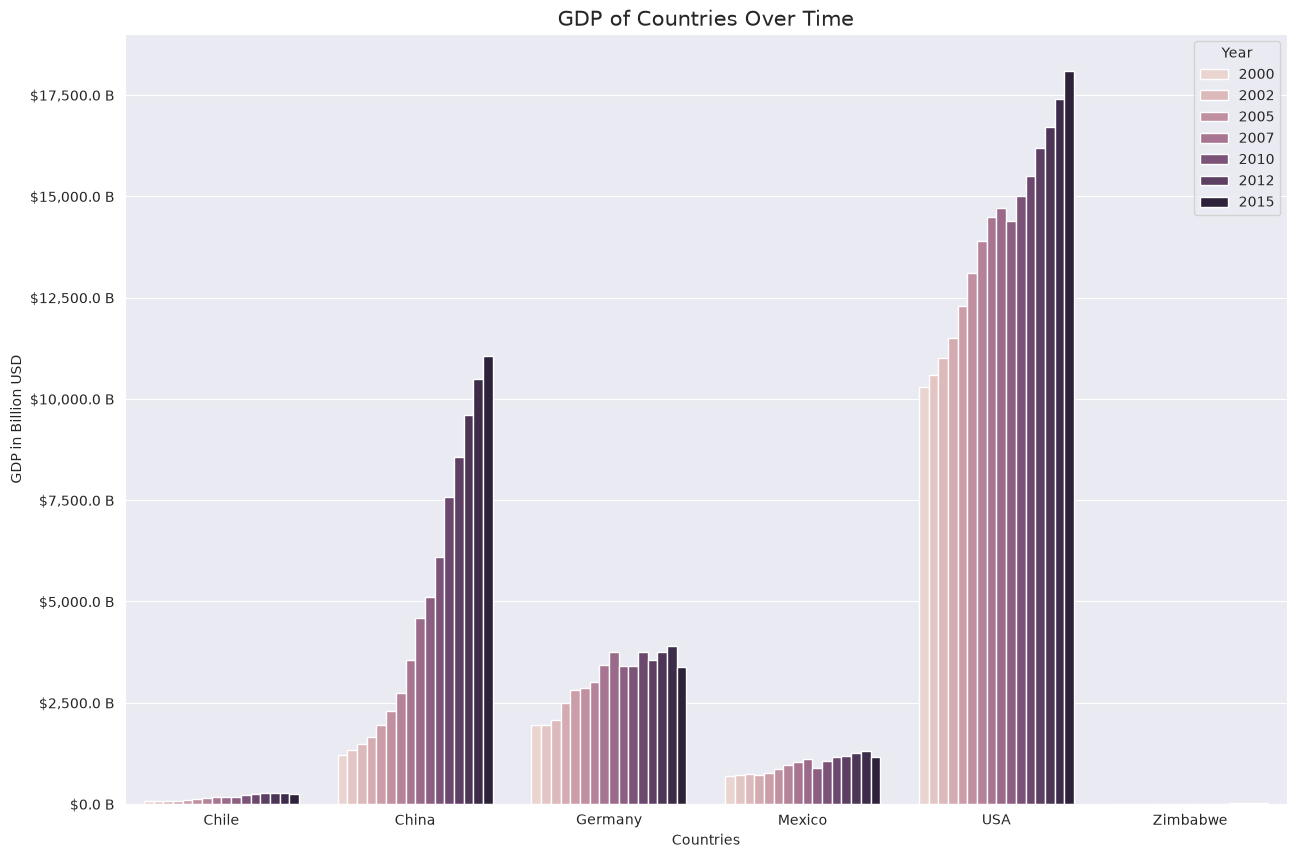

In [4]:
sns.set_palette('bright')
sns.set_style('darkgrid')

fig = plt.figure(figsize = (15, 10))
fig = fig.add_subplot()

sns.barplot(data = df, x = 'Country', y = 'GDP', hue = 'Year')
fig.set_title('GDP of Countries Over Time', fontsize = 15)
fig.set_xlabel('Countries')
fig.set_ylabel('GDP in Billion USD')

fmt = '${x:,.1f} B'
tick = mtick.StrMethodFormatter(fmt)
fig.yaxis.set_major_formatter(tick)

    Country           GDP
0     Chile    169.788845
1     China   4957.713750
2   Germany   3094.775625
3    Mexico    976.650625
4       USA  14075.000000
5  Zimbabwe      9.062580


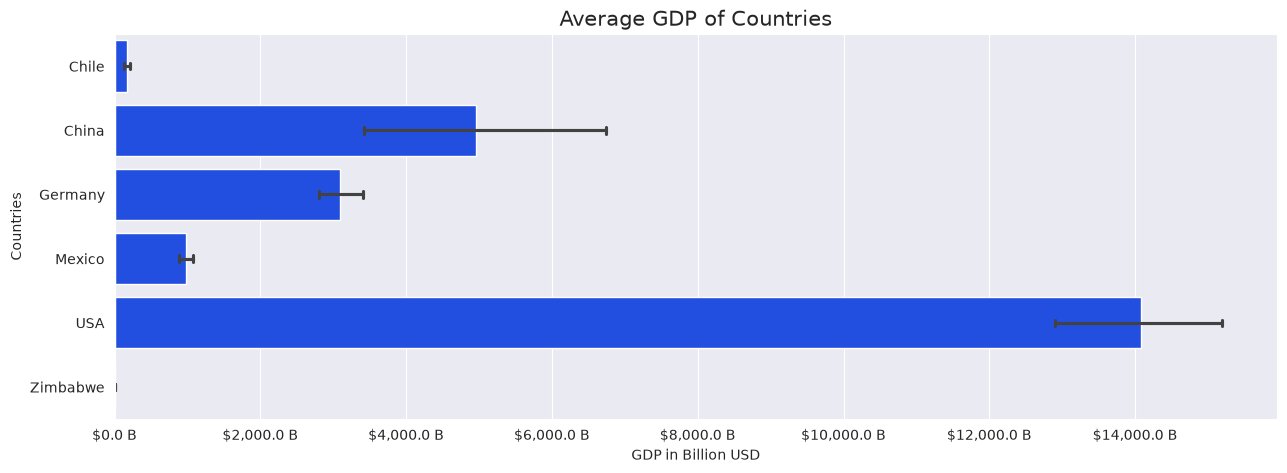

In [5]:
avg_gdp = df.groupby(['Country']).GDP.mean().reset_index()
print(avg_gdp)
fig = plt.figure(figsize = (15, 5))
fig = fig.add_subplot()

sns.barplot(data = df, y = 'Country', x = 'GDP', capsize = .1)
fig.set_title('Average GDP of Countries', fontsize = 15)
fig.set_ylabel('Countries')
fig.set_xlabel('GDP in Billion USD')

fmt = '${x:,.1f} B'
tick = mtick.StrMethodFormatter(fmt)
fig.xaxis.set_major_formatter(tick)

Text(0.5, 0.98, 'GDP Line Plot for Each Country over Time')

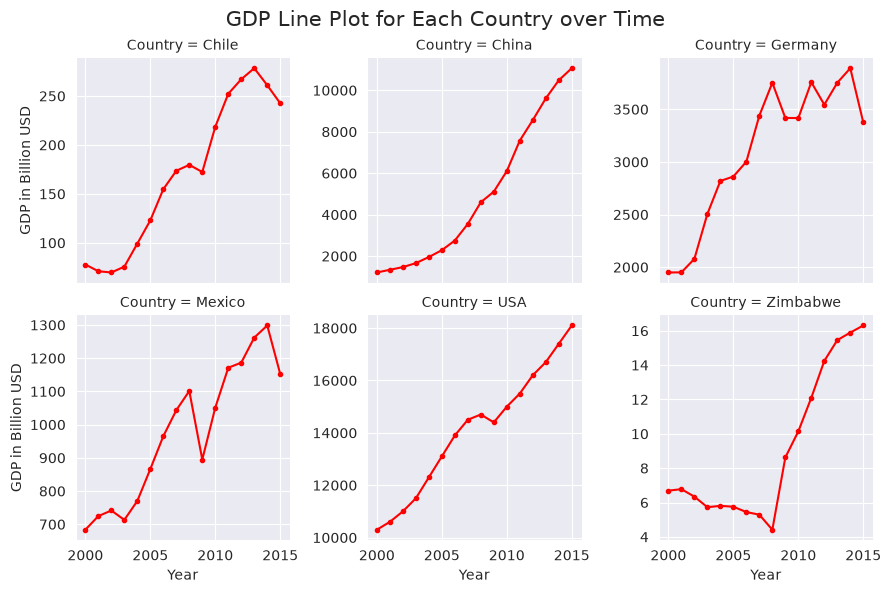

In [6]:
fig = sns.FacetGrid(data=df, col='Country', col_wrap=3, sharey = False)
fig = fig.map(plt.plot, 'Year', 'GDP', color = 'r', marker = '.')

fig.set_xlabels('Year')
fig.set_ylabels('GDP in Billion USD')
#fig.add_legend()

plt.subplots_adjust(top=0.9)
fig.fig.suptitle('GDP Line Plot for Each Country over Time', fontsize = 15)

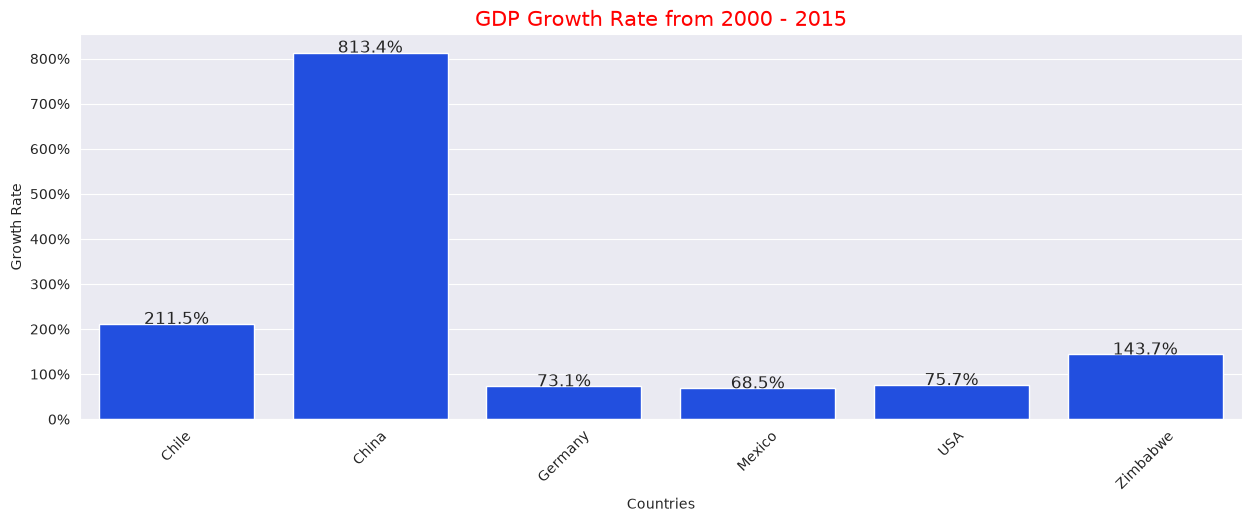

In [7]:
gdp_growth_rate = pd.DataFrame({'Country': df.Country.unique(),
                'gdp_2000': df.loc[(df['Year']==2000), 'GDP'].values,
                'gdp_2015': df.loc[(df['Year']==2015), 'GDP'].values})

gdp_growth_rate['g_rate'] = ((gdp_growth_rate.gdp_2015 - gdp_growth_rate.gdp_2000) / gdp_growth_rate.gdp_2000) * 100
#print(growth_rate)

fig = plt.figure(figsize = (15, 5))
fig = fig.add_subplot()

sns.set_palette('Accent')
sns.barplot(data = gdp_growth_rate, y = 'g_rate', x = 'Country' )

fig.set_xlabel('Countries')
plt.xticks(rotation = 45)
fig.set_ylabel('Growth Rate')
fig.set_title('GDP Growth Rate from 2000 - 2015', fontsize = 15, color = 'r')

fmt = '{x:.0f}%'
tick = mtick.StrMethodFormatter(fmt)
fig.yaxis.set_major_formatter(tick)



for p in fig.patches:
    value = '{:.1f}%'.format(p.get_height()) 
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    fig.annotate(value, (x, y), ha='center', fontsize = 12)

### 2. Analysising Data for Life Expectancy

    Country     LEABY
0     Chile  78.94375
1     China  74.26250
2   Germany  79.65625
3    Mexico  75.71875
4       USA  78.06250
5  Zimbabwe  50.09375


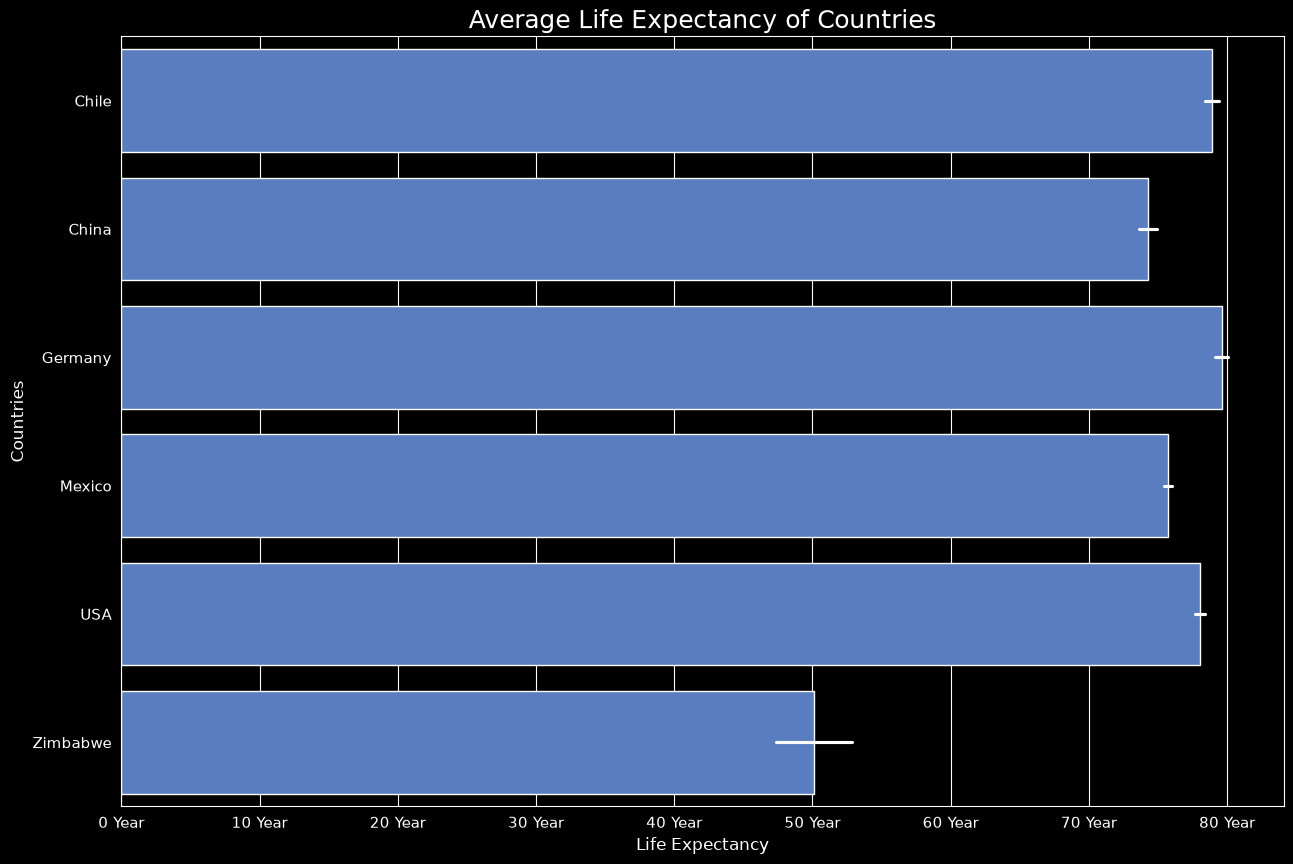

In [8]:
avg_leaby = df.groupby(['Country']).LEABY.mean().reset_index()
print(avg_leaby)
sns.set_style('darkgrid', {'axes.facecolor':'black', 'figure.facecolor':'black'})
sns.set_palette('muted')

fig = plt.figure(figsize = (15, 10))
fig = fig.add_subplot()

fig = sns.barplot(data = df, x = 'LEABY', y = 'Country', err_kws={'color': 'w'})
fig.tick_params(axis='both', colors='white', labelsize=11)
fig.set_xlabel('Life Expectancy', color = 'w', fontsize = 12)
fig.set_ylabel('Countries', color = 'w', fontsize = 12)
fig.set_title('Average Life Expectancy of Countries', fontsize = 18, color = 'w')

#legend = plt.legend(loc=2, fontsize=12)
#plt.setp(legend.get_texts(), color='w')

fmt = '{x:.0f} Year'
tick = mtick.StrMethodFormatter(fmt)
fig.xaxis.set_major_formatter(tick)


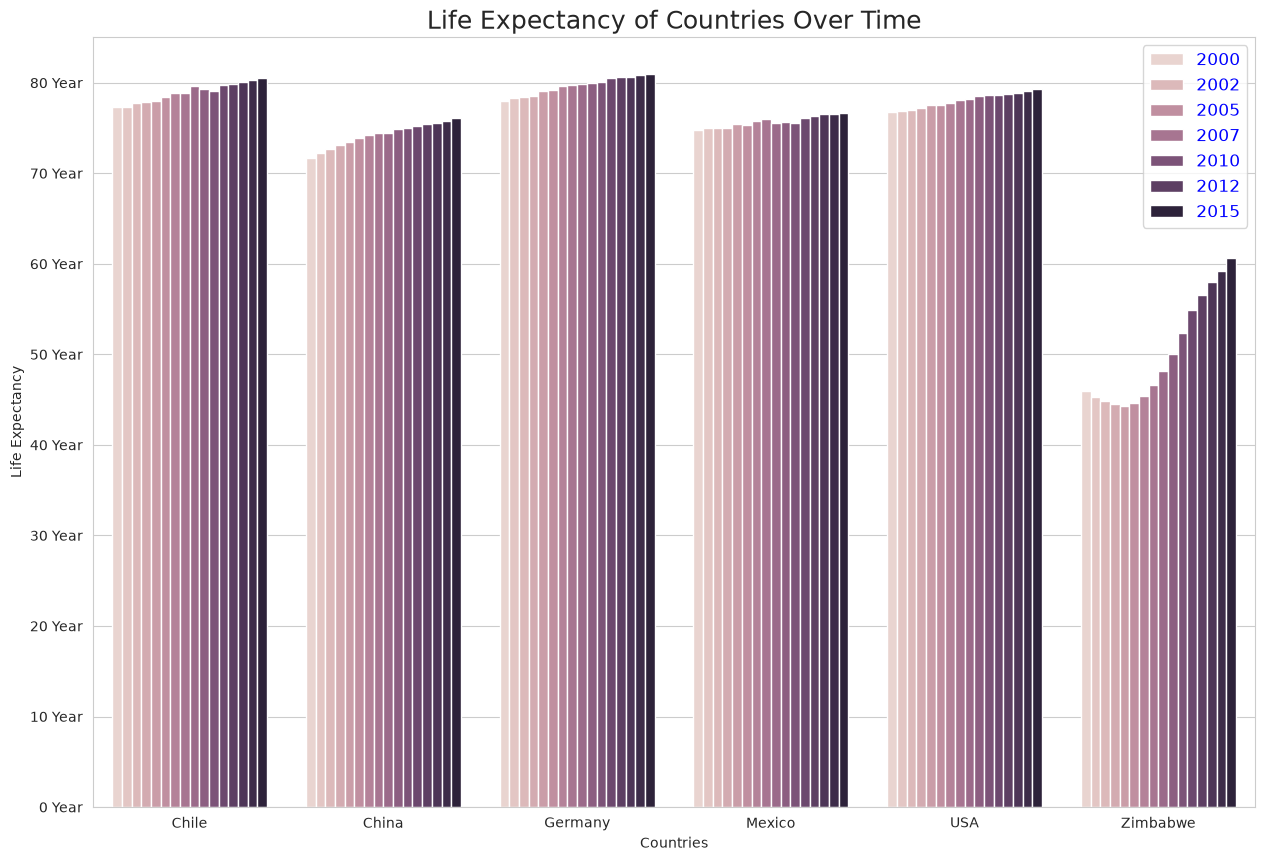

In [9]:
sns.set_style('whitegrid')
sns.set_palette('muted')

fig = plt.figure(figsize = (15, 10))
fig = fig.add_subplot()

fig = sns.barplot(data = df, y = 'LEABY', x = 'Country', hue = 'Year')
fig.set_ylabel('Life Expectancy')
fig.set_xlabel('Countries')
fig.set_title('Life Expectancy of Countries Over Time', fontsize = 18)
legend = plt.legend(bbox_to_anchor=(1, 1), fontsize=12)
plt.setp(legend.get_texts(), color = 'b')

fmt = '{x:.0f} Year'
tick = mtick.StrMethodFormatter(fmt)
fig.yaxis.set_major_formatter(tick)

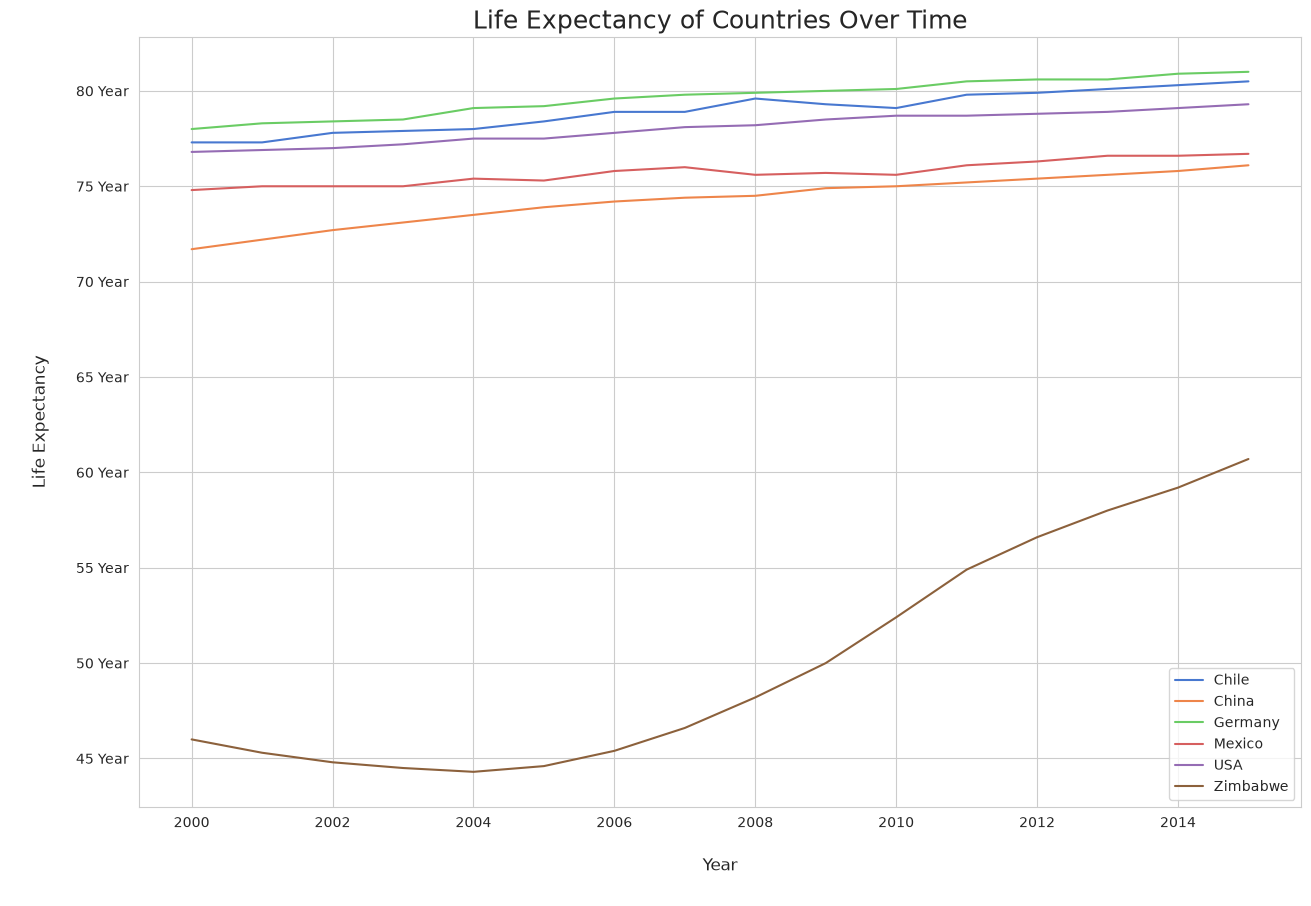

In [10]:
sns.set_style('whitegrid')
sns.set_palette('muted')

fig = plt.figure(figsize = (15, 10))
fig = fig.add_subplot()

fig = sns.lineplot(data = df, y = 'LEABY', x = 'Year', hue = 'Country')
fig.set_ylabel('\nLife Expectancy\n', fontsize = 12)
fig.set_xlabel('\nYear\n', fontsize = 12)
fig.set_title('Life Expectancy of Countries Over Time', fontsize = 18)
plt.legend(loc = 4)

fmt = '{x:.0f} Year'
tick = mtick.StrMethodFormatter(fmt)
fig.yaxis.set_major_formatter(tick)

Text(0.5, 0.98, 'Line Plot of Life Expectancy for Each Country over Time')

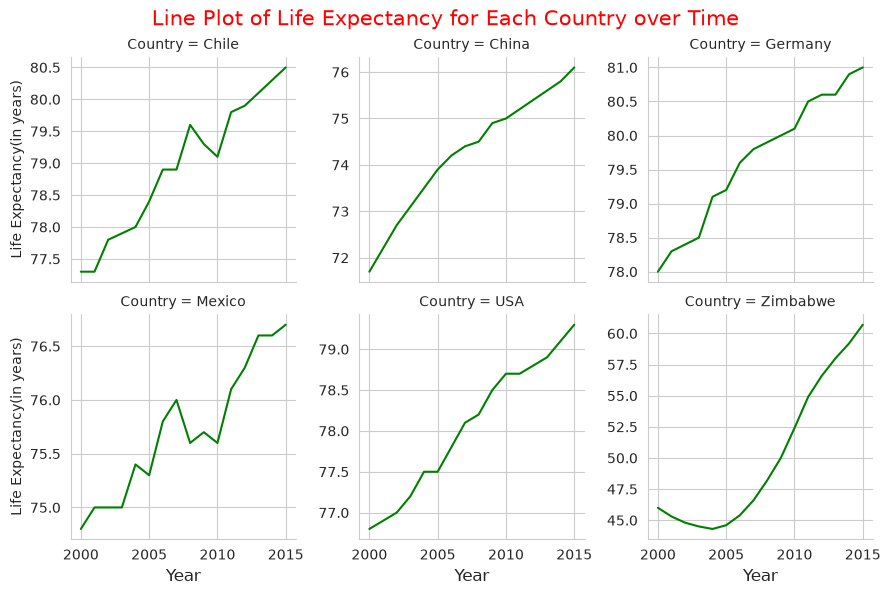

In [11]:
fig = sns.FacetGrid(data = df, col = 'Country', sharey = False, col_wrap = 3)
fig = fig.map(plt.plot, 'Year', 'LEABY', color = 'g')

fig.set_xlabels('Year', fontsize = 12)
fig.set_ylabels('Life Expectancy(in years)')

plt.subplots_adjust(top=0.9)
fig.fig.suptitle('Line Plot of Life Expectancy for Each Country over Time', fontsize = 15, color = 'r')

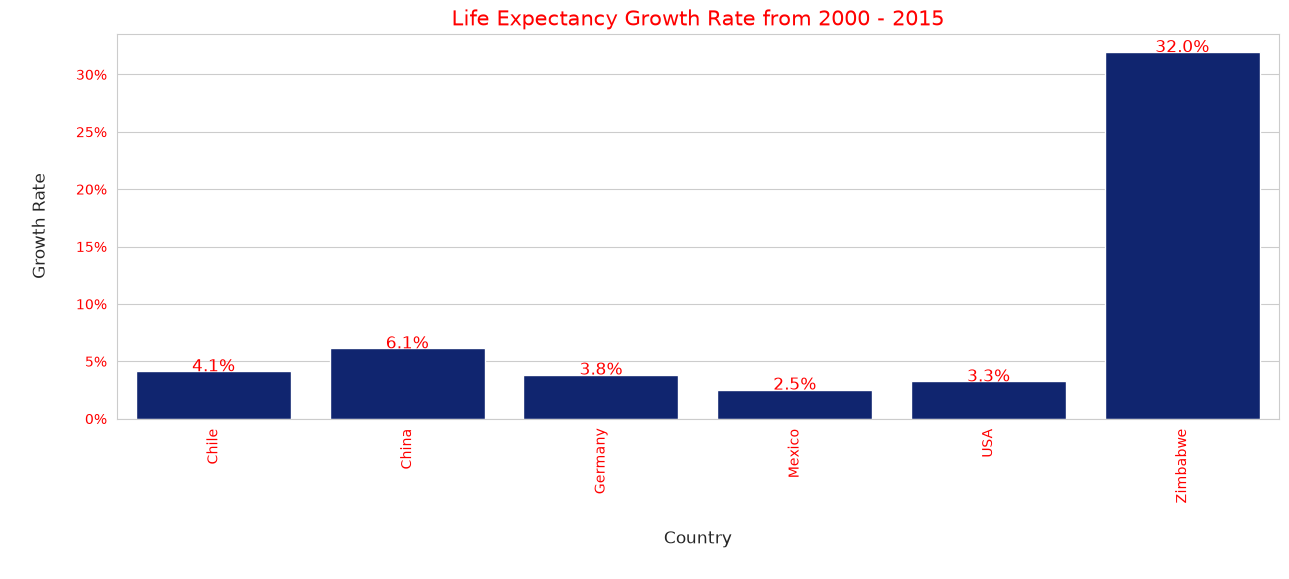

In [12]:
leaby_growth_rate =  pd.DataFrame({'Country': df.Country.unique(),
                                   'leaby_2000': df.loc[(df['Year'] == 2000), 'LEABY'].values,
                                   'leaby_2015': df.loc[(df['Year'] == 2015), 'LEABY'].values})
leaby_growth_rate['g_rate'] = ((leaby_growth_rate.leaby_2015 - leaby_growth_rate.leaby_2000) / leaby_growth_rate.leaby_2000) * 100
#print(leaby_growth_rate)

sns.set_palette('dark')
fig = plt.figure(figsize = (15, 5))
fig = fig.add_subplot()

sns.barplot(data = leaby_growth_rate, x = 'Country', y = 'g_rate')

fig.set_xlabel('\nCountry\n', fontsize = 12)
plt.xticks(rotation = 90, color = 'r')
plt.yticks(color = 'r')
fig.set_ylabel('\nGrowth Rate\n', fontsize = 12)
fig.set_title('Life Expectancy Growth Rate from 2000 - 2015', fontsize = 15, color = 'r')

fmt = '{x:.0f}%'
tick = mtick.StrMethodFormatter(fmt)
fig.yaxis.set_major_formatter(tick)

for p in fig.patches:
    value = '{:.1f}%'.format(p.get_height())
    x = p.get_x() + p.get_width() /2
    y = p.get_height()
    fig.annotate(value, (x, y), ha='center', fontsize = 12, color = 'r')

### 3. Analysing if there is any relation between GDP Growth Rate and LEABY & LEABY Distribution

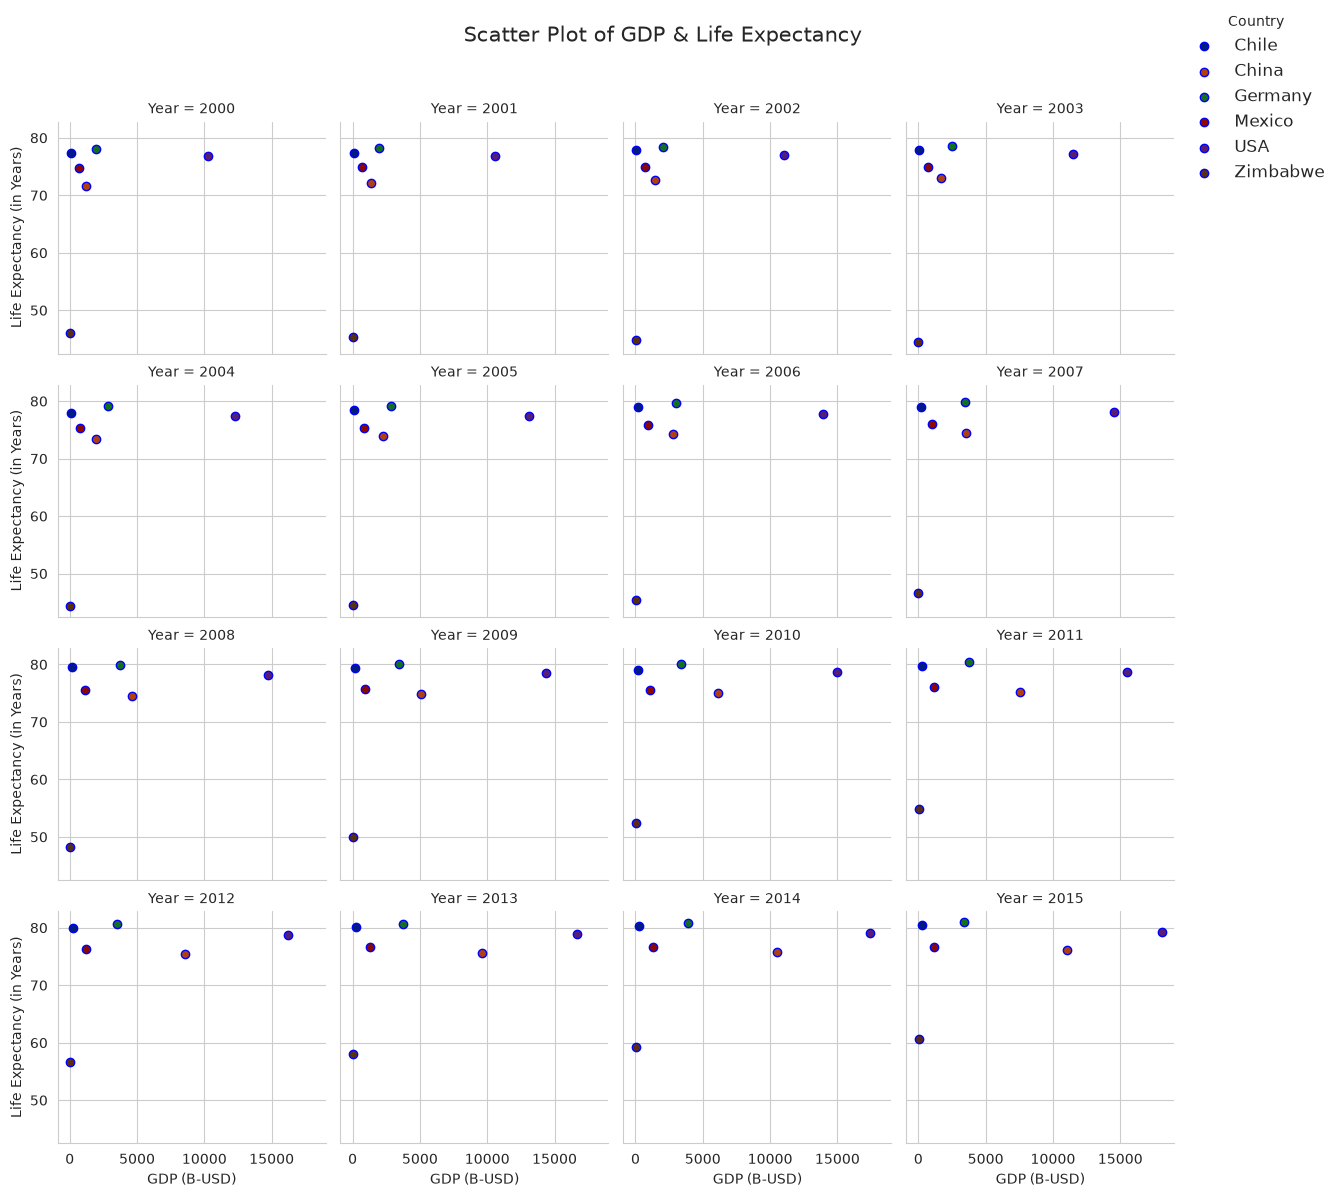

In [13]:
#sns.scatterplot(data = df, x = 'GDP', y = 'LEABY')
fig = sns.FacetGrid(data = df, col = 'Year', hue = 'Country', col_wrap = 4)
fig = fig.map(plt.scatter, 'GDP', 'LEABY', edgecolor = 'b').add_legend(fontsize = 12, loc = 1)

fig.set_xlabels('GDP (B-USD)')
fig.set_ylabels('Life Expectancy (in Years)')
plt.subplots_adjust(top=0.9)
fig.fig.suptitle('Scatter Plot of GDP & Life Expectancy', fontsize = 15);

In [14]:
covariance = np.cov(df.GDP, df.LEABY)
corelation, p = stats.pearsonr(df.GDP, df.LEABY)
rvalue, pvalue = stats.spearmanr(df.GDP,df.LEABY)
print(rvalue)
print(covariance)
print(corelation)

0.4472391846883402
[[2.70146436e+07 1.90386943e+04]
 [1.90386943e+04 1.13910417e+02]]
0.343206748449156


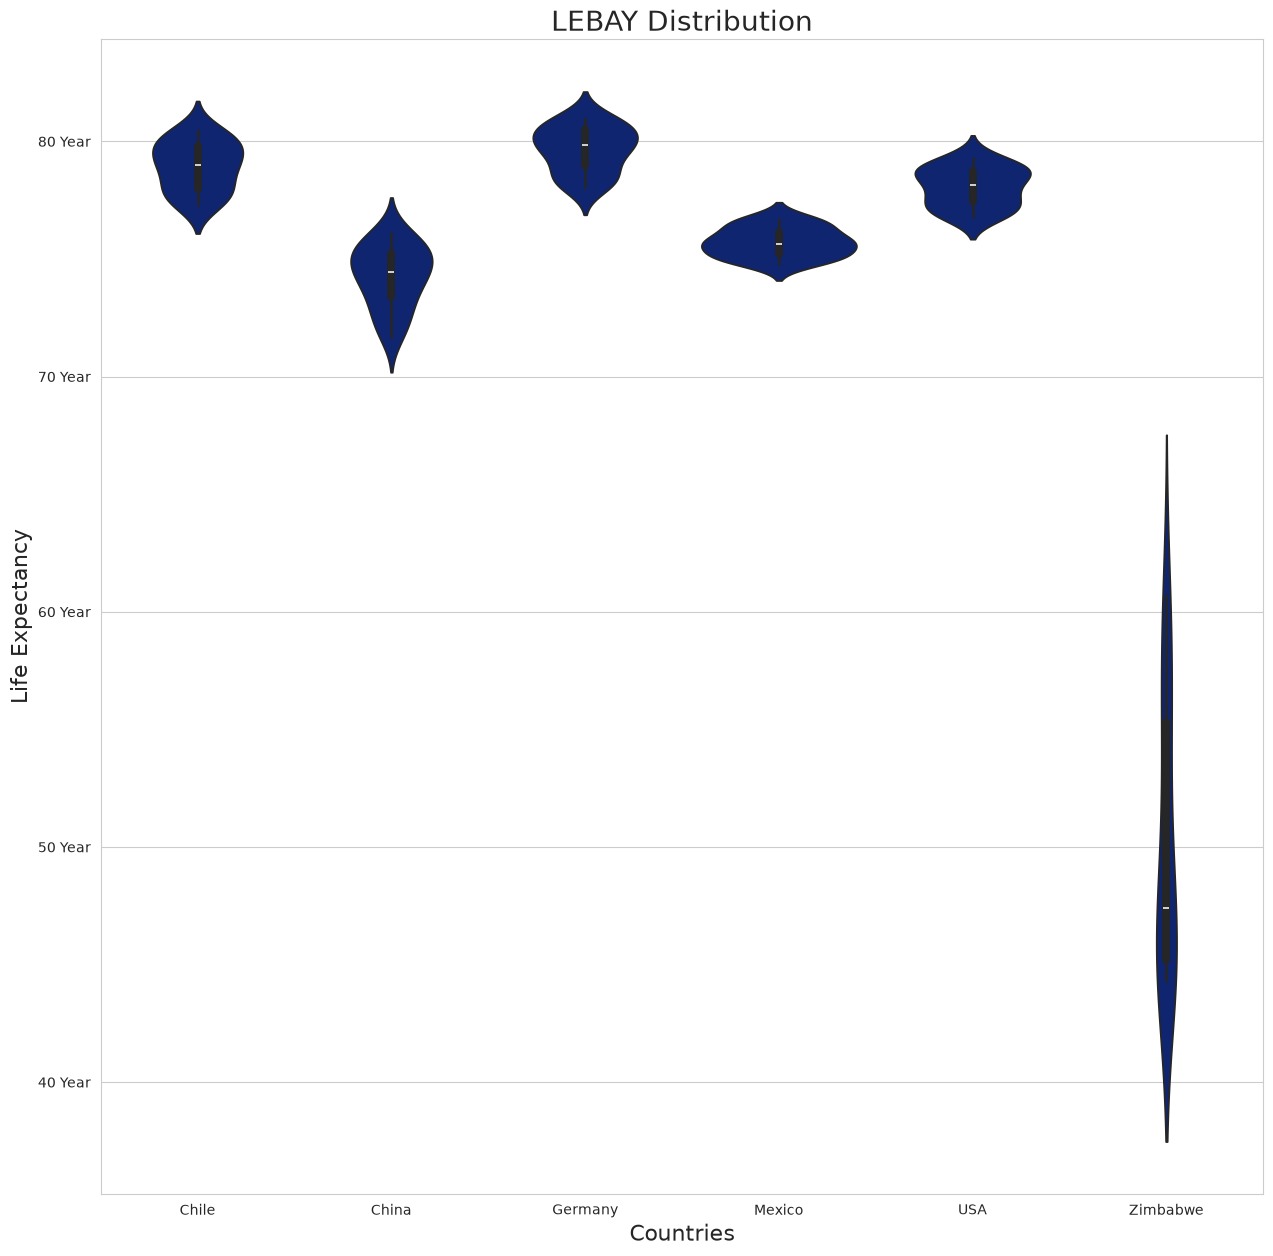

In [15]:
fig = plt.subplots(figsize=(15, 15)) 
fig = sns.violinplot(data=df, x='Country', y='LEABY');
plt.ylabel('Life Expectancy', fontsize = 16)
plt.title('LEBAY Distribution', fontsize = 20)
plt.xlabel('Countries', fontsize = 16);

fmt = '{x:.0f} Year'
tick = mtick.StrMethodFormatter(fmt)
fig.yaxis.set_major_formatter(tick)

## Conclusions

**GDP growth**
- Every country grew its GDP between 2000 and 2015. China's growth was exceptional (**+813%**), followed by Chile (**+211%**); the USA grew by **+75%**.
- Most countries saw GDP fall in 2008–2009 during the global financial crisis — China and Zimbabwe were the exceptions. Germany's GDP fluctuated year to year after 2009, with a notable drop in 2015.

| Country | Average GDP 2000–2015 (USD billions) |
|---|---:|
| USA | 14,075 |
| China | 4,958 |
| Germany | 3,095 |
| Mexico | 977 |
| Chile | 170 |
| Zimbabwe | 9 |

**Life expectancy**
- Life expectancy rose in all six countries. Zimbabwe improved the most (**+32%**), although it first declined between 2000 and 2004.

| Country | Average life expectancy (years) |
|---|---:|
| Germany | 79.7 |
| Chile | 78.9 |
| USA | 78.1 |
| Mexico | 75.7 |
| China | 74.3 |
| Zimbabwe | 50.1 |

**GDP ↔ life expectancy**
- Pearson (r ≈ 0.34) and Spearman (ρ ≈ 0.45) coefficients indicate a moderate positive correlation; within each country the relationship is much stronger, as the per-year scatter plots show.
- With only six countries and 16 years, this is evidence of association, not causation.

**Distributions**
- Chile and Germany have very similar distributions (≈76–82 years). The USA is similar in shape but centred ~1.5 years lower than Germany.
- China's distribution is wider (≈70–77.5 years) than Mexico's (≈74–77.5 years).
- Zimbabwe has by far the widest spread (≈37.5–67.5 years) and the lowest average (~50 years).